In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv("global-data-on-sustainable-energy.csv")

In [6]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [7]:
df.shape

(3649, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

In [9]:
df.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


In [10]:
df.isnull().sum()

,0
Entity,0
Year,0
Access to electricity (% of population),10
Access to clean fuels for cooking,169
Renewable-electricity-generating-capacity-per-capita,931
Financial flows to developing countries (US $),2089
Renewable energy share in the total final energy consumption (%),194
Electricity from fossil fuels (TWh),21
Electricity from nuclear (TWh),126
Electricity from renewables (TWh),21


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
df.isnull().sum()

,0
Entity,0
Year,0
Access to electricity (% of population),0
Access to clean fuels for cooking,0
Renewable-electricity-generating-capacity-per-capita,0
Financial flows to developing countries (US $),0
Renewable energy share in the total final energy consumption (%),0
Electricity from fossil fuels (TWh),0
Electricity from nuclear (TWh),0
Electricity from renewables (TWh),0


This dataset contains sustainability and renewable energy information for multiple countries. It includes features such as renewable energy share, electricity access, carbon emissions, GDP, and energy usage. The objective is to analyze the dataset and group countries with similar characteristics using K-Means Clustering

In [13]:
numeric_df = df.select_dtypes(include=np.number)

In [14]:
numeric_df.head()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
0,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,11.986707,3.441610,13283.774348,652230.0,33.93911,67.709953
1,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,11.986707,3.441610,13283.774348,652230.0,33.93911,67.709953
2,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,11.986707,3.441610,179.426579,652230.0,33.93911,67.709953
3,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,11.986707,8.832278,190.683814,652230.0,33.93911,67.709953
4,2004,20.064968,10.9,7.75,94224000.0,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,11.986707,1.414118,211.382074,652230.0,33.93911,67.709953


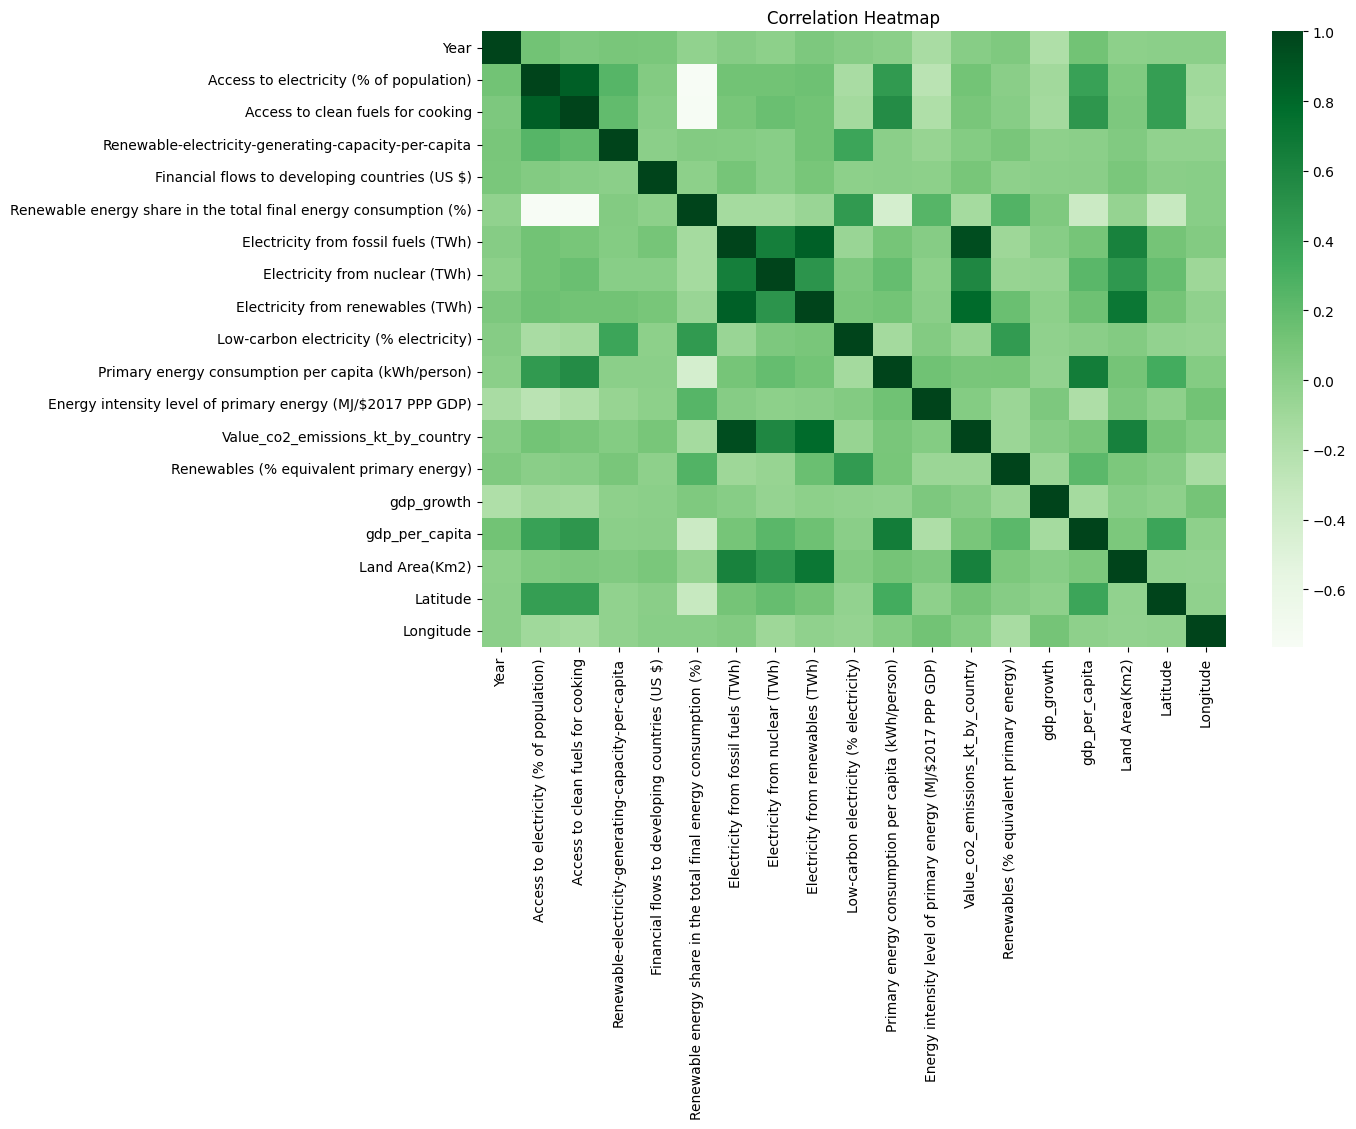

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="Greens",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

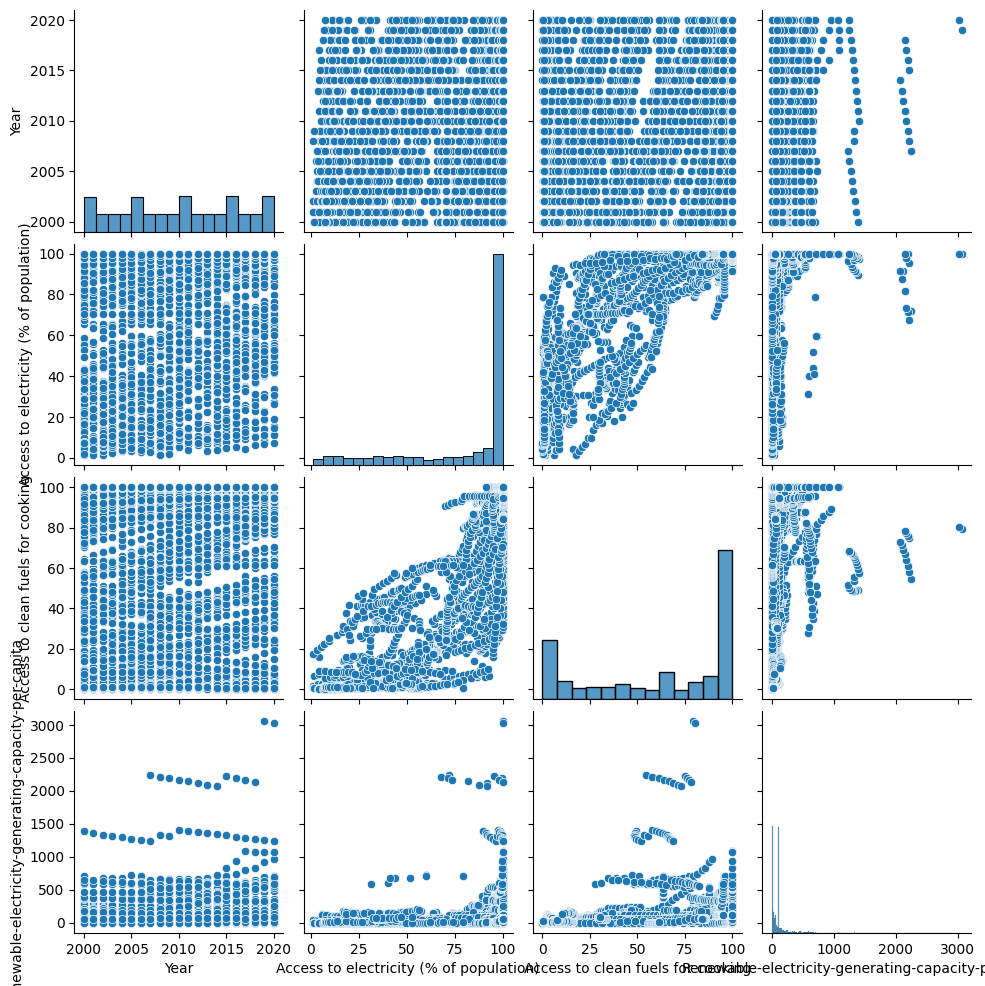

In [16]:
sns.pairplot(numeric_df.iloc[:, :4])

plt.show()

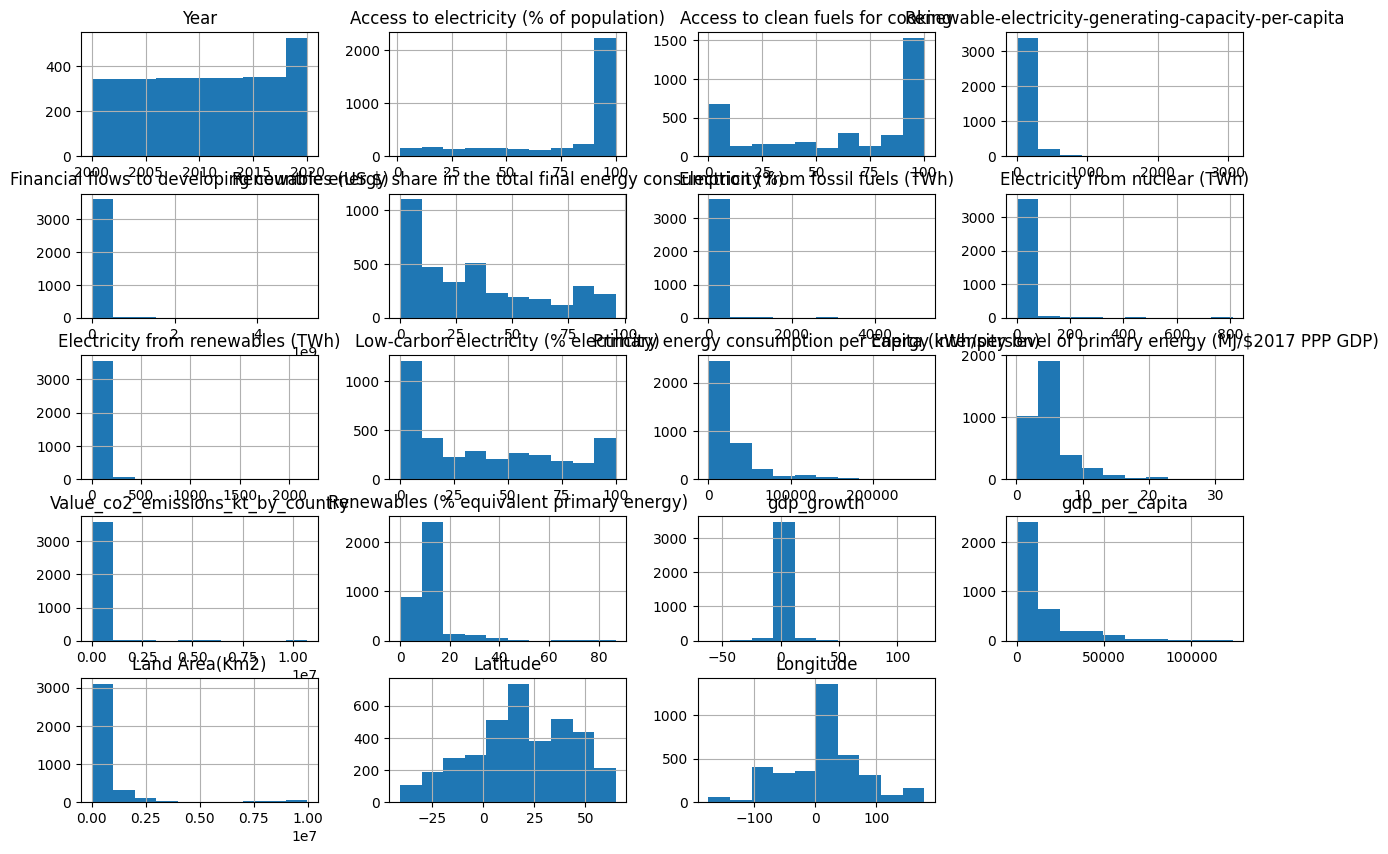

In [17]:
numeric_df.hist(
    figsize=(15,10)
)

plt.show()

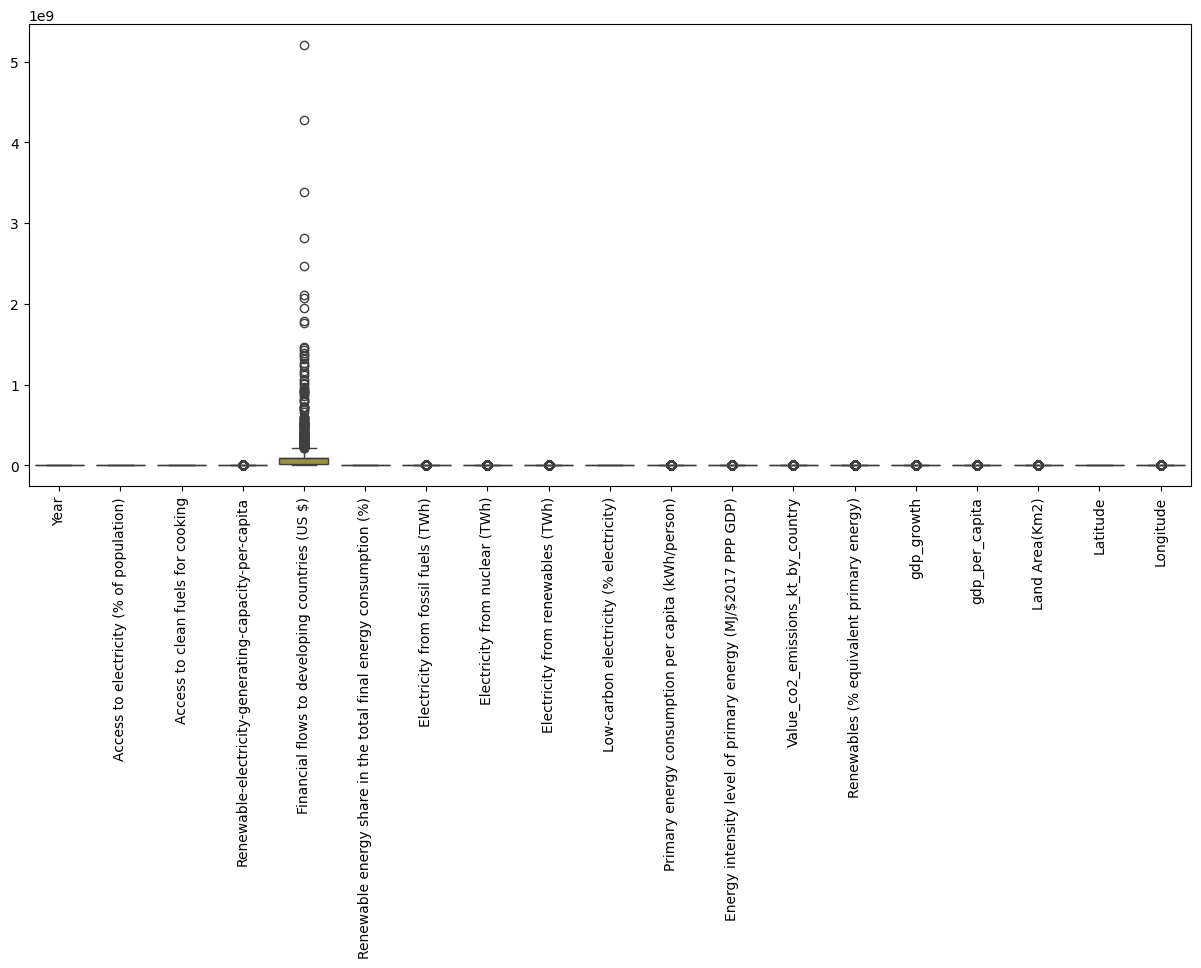

In [18]:
plt.figure(figsize=(15,6))

sns.boxplot(data=numeric_df)

plt.xticks(rotation=90)

plt.show()

In [19]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)

In [20]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

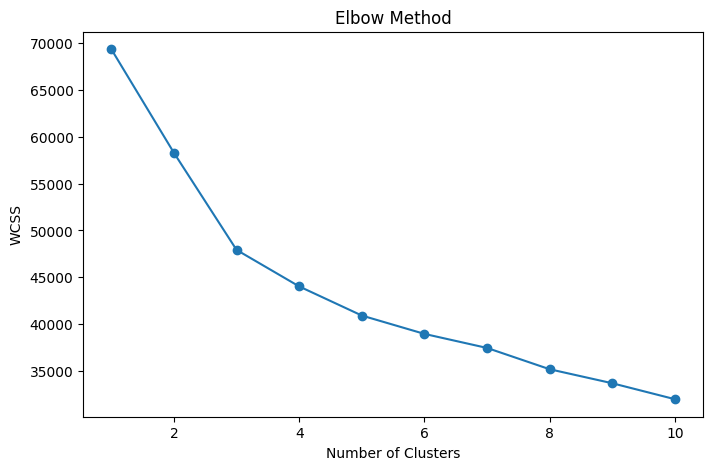

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

In [23]:
df["Cluster"] = clusters

In [24]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude,Cluster
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,1.64,760.000000,11.986707,3.441610,13283.774348,60,652230.0,33.93911,67.709953,0
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,1.74,730.000000,11.986707,3.441610,13283.774348,60,652230.0,33.93911,67.709953,0
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,1.40,1029.999971,11.986707,3.441610,179.426579,60,652230.0,33.93911,67.709953,0
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,1.40,1220.000029,11.986707,8.832278,190.683814,60,652230.0,33.93911,67.709953,0
4,Afghanistan,2004,20.064968,10.9,7.75,94224000.0,44.24,0.33,0.0,0.56,...,1.20,1029.999971,11.986707,1.414118,211.382074,60,652230.0,33.93911,67.709953,0


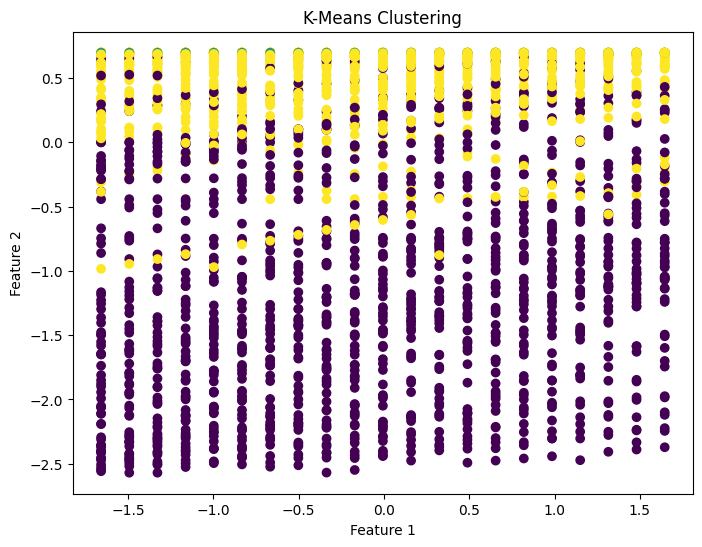

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

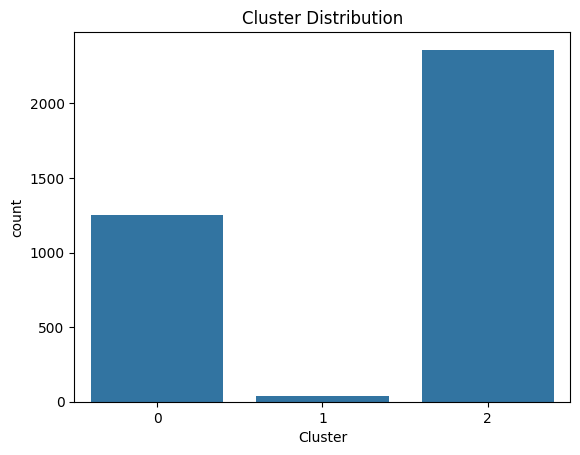

In [26]:
sns.countplot(
    x="Cluster",
    data=df
)

plt.title("Cluster Distribution")

plt.show()

In [27]:
score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.20813119635445723


In [28]:
df.groupby("Cluster").mean(numeric_only=True)

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
Cluster,,,,,,,,,,,,,,,,,,,
0,2009.483613,43.583524,16.650844,39.392174,8.285725e+07,63.874791,9.990380,0.394950,3.912273,44.107384,2773.202887,6.089899,3.482052e+04,11.938708,4.376600,2161.653871,4.697383e+05,3.593316,24.796066
1,2010.692308,99.712777,81.656410,180.290961,1.454489e+08,11.805547,3126.820000,491.088718,747.162564,27.773185,55597.974385,6.840120,6.383530e+06,7.457737,5.009683,29610.029702,9.724337e+06,36.523203,-3.447527
2,2010.321747,97.336707,87.665849,151.135131,9.940502e+07,16.417501,51.851611,12.476982,22.647594,33.075888,37432.043906,4.867009,1.232872e+05,12.087036,2.919852,18912.027319,5.696076e+05,25.714890,9.835772


Conclusion

The dataset was cleaned by filling missing values and analyzed using visualizations such as heatmaps, pairplots, histograms, and boxplots. The numerical features were standardized before applying the K-Means algorithm. The Elbow Method was used to select the number of clusters, and the Silhouette Score was calculated to evaluate the clustering quality. The resulting clusters group countries with similar sustainability and renewable energy characteristics.